# Régression linéaire et applications au CAPM

### Séparer les rendements

- Le CAPM est basé sur deux éléments: un portefeuille de marché $M$ et un coéfiicient $\beta$ qui relie le portefeuille au marché à celui d'un actif.
- Dans la théorie $M$ contient tous les actifs du marché, mais en pratique on prendra un indice tel que le cac40 où le S\&P500.

On considère un portefeuille $P$ avec un surplus de rentabilité $r_{p}$ et le portefeuille de marché $M$ avec un surplus de rentabilité $r_{m}$. Alors le $\beta$ du portefeuille $P$ est égal à:

$$ \beta_{P} = \frac{\text{Cov}(r_{P},r_{M})}{\text{Var}(r_{M})} $$

L'estimateur le plus simple $\beta_{P}$ est donné par la régréssion linéaire du surplus de rentabilité  $r_{P}(t)$ sur le surplus de rentabilité $r_{M}(t)$ pour la même période:

$$ r_{P}(t) = \alpha_{P} + \beta_{P}r_{M}(t) + \epsilon_{P}(t)  $$

Ces estimations peuvent être utilisés pour faire des prédictions. Le paramètre 
Beta est une façon de séparer le risque et le rendement en deux parties : une composante du marché et une composante résiduelle:


$$ r_{P} = \beta_{P}r_{M} + \theta_{P} $$


Le rendement résiduel $\theta_{P}$ sera corrélé avec le rendement du marché $r_{M}$ et ainsi de la variance du portefeuille $P$ est:


$$ \sigma_{P}^{2} = \beta^{2}_{P}\sigma_{M}^{2} + \omega_{P}^{2} $$


où $\omega_{P}^{2}$ est la variance résiduelle du portefeuille.

Le **CAPM** dit que la moyenne du rendement résiduel sur tous les actifs et tous les portefeuilles est égal à zéro i.e. $E[\theta_{P}]=0$. Ainsi, la moyenne du surplus de rentabilité du portefeille $E[r_{P}]=\mu_{P}$ est entièrement déterminée par la moyenne du surplus de rentabilité du portefeille de marché, $E[r_{M}]=\mu_{M}$ et $\beta$, i.e:

$$ E[r_{P}] = \beta_{P}E[r_{M}] =  \beta_{P}\mu_{M} $$

#### Exemple

On considère l'indice S&P500 comme 'le Marché', Macy's (**M**) comme un exemple d'actif, et le  1-mois bon de trésorie comme ASR  (on convertira en taux journalier). 

In [5]:
import numpy as np
import pandas as pd
from pandas_datareader import DataReader
from datetime import datetime
import yfinance as yf
import matplotlib.pyplot as plt
import statsmodels.api as sm
%matplotlib inline 

In [4]:
pd.__version__

!pip install pandas_datareader 
!pip install yfinance
!pip install statsmodels


   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ------------ --------------------------- 2.9/9.5 MB 18.7 MB/s eta 0:00:01
   ------------------------- -------------- 6.0/9.5 MB 16.3 MB/s eta 0:00:01
   ---------------------------------- ----- 8.1/9.5 MB 13.6 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 12.0 MB/s  0:00:00

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- -----------

On charge les données du ASR et on convertit aux rendements journaliers. 

In [6]:
one_mon = DataReader('DGS1MO', 'fred',datetime(2012,1,1), datetime(2015,1,1))
#print(one_mon)
one_day = np.log(1+one_mon)/365 # actif non risqué 
#print(one_day['DGS1MO'].values)

On charge les rendements du S&P500.

C:\Users\lione\AppData\Local\Temp\ipykernel_43004\1944665480.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy = yf.download('SPY', datetime(2012,1,1), datetime(2015,1,1))
[*********************100%***********************]  1 of 1 completed


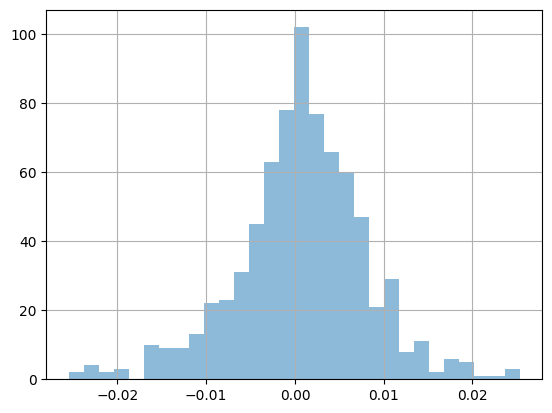

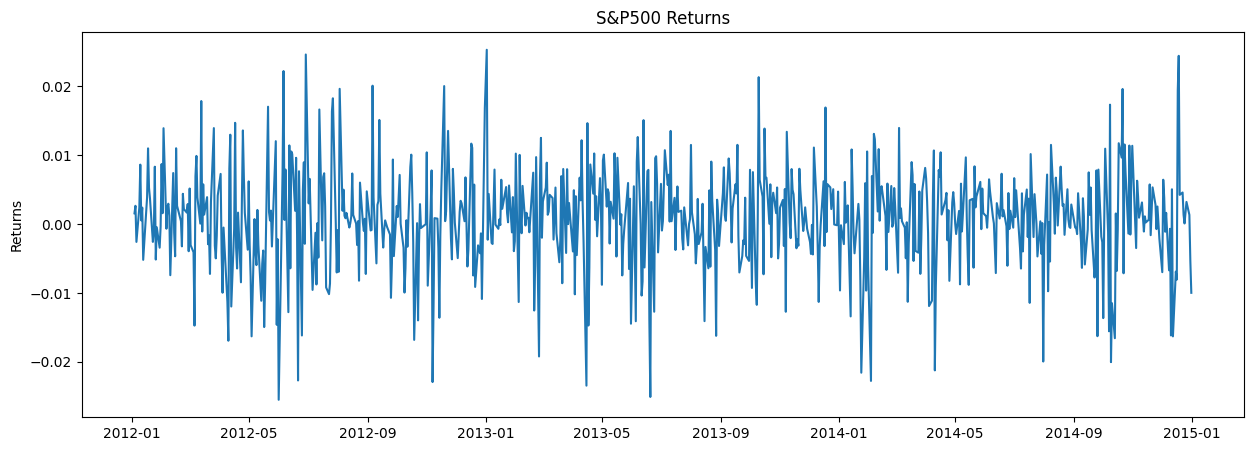

In [41]:
spy = yf.download('SPY', datetime(2012,1,1), datetime(2015,1,1)) 


# S_t0, S_t1, ...., S_tn portefeuille de marché
#time grid :  t0<t1<t2...<tn
# rendements: S_t1/S_t0, S_t2/S_t1, ..., S_tn/S_tn-1
# log rendements: log(S_t1/S_t0), log(S_t2/S_t1),...,log(S_tn/S_tn-1)

# Modèle de Black Scholes sous la proba risque neutre Q : 
#log(S_ti+1/S_ti)= (r-0.5*vol**2)*(t_i+1-t_i)+ vol*(W_ti+1-W_ti) 
# =(r-0.5*vol**2)*(t_i+1-t_i)+ vol*sqrt(t_i+1-t_i)*G_i où  G_i~N(0,1)  iid 


spy_returns = pd.DataFrame(np.log(spy['Close']).diff())


#x = np.array([1, 2, 4, 7, 0])
#np.diff(x)
#array([ 1,  2,  3, -7])


spy_returns.index = spy.index[0:spy.index.shape[0]]

spy_returns.columns = ['S&P500 Returns']



spy_returns['S&P500 Returns'].hist(bins=30,alpha=0.5) # histogramme
#print(spy_returns)
plt.figure(figsize=(15,5));
plt.plot(spy_returns);
plt.ylabel('Returns');
plt.title('S&P500 Returns');
plt.show();

On considère un exemple d'actif dans cet indice par exemple  Macy's (**M**):

C:\Users\lione\AppData\Local\Temp\ipykernel_43004\1698874278.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  m = yf.download('M',  datetime(2012,1,1), datetime(2015,1,1)) # actif risqué
[*********************100%***********************]  1 of 1 completed


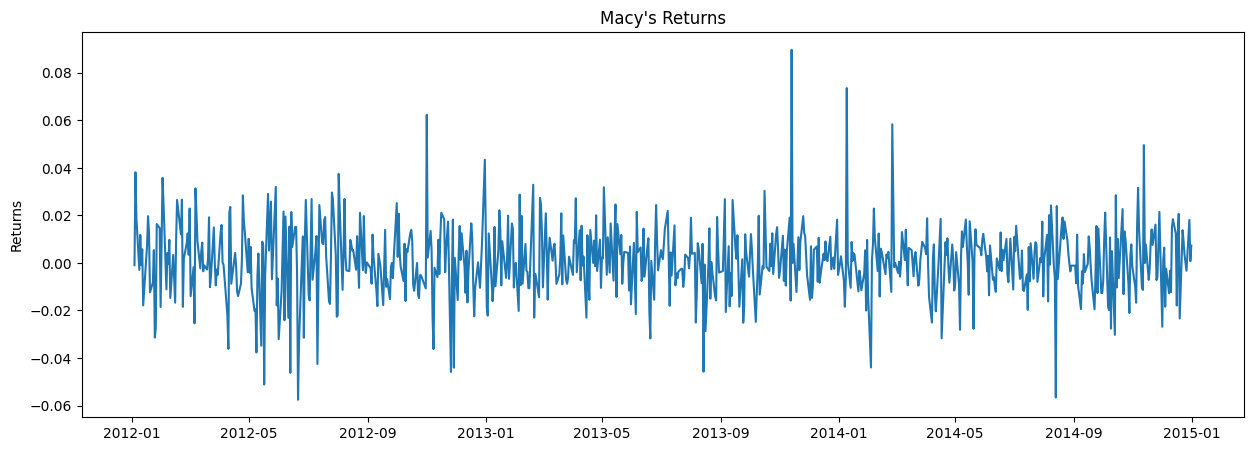

<Axes: >

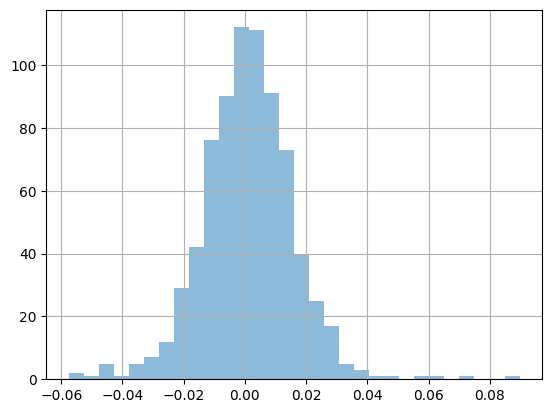

In [42]:
m = yf.download('M',  datetime(2012,1,1), datetime(2015,1,1)) # actif risqué
#Complétez log rendement de l'indice 'M' :
m_returns = pd.DataFrame(np.log(m['Close']).diff())
m_returns.index = m.index[0:m.index.shape[0]]

m_returns.columns = ["Macy's Returns"]
#print(m_returns)
plt.figure(figsize=(15,5));
plt.plot(m_returns);
plt.ylabel('Returns');
plt.title("Macy's Returns");
plt.show();
m_returns["Macy's Returns"].hist(bins=30,alpha=0.5)

On doit fusionner les trois jeux de données afin d'être sûr d'avoir la même échelle de temps et puis on calcule le surplus de rentabilité. 

            Excess Macy's Returns  Excess S&P500 Returns  Risk-free rate
2012-01-04              -0.000946               0.001540        0.000027
2012-01-05               0.038133               0.002632        0.000027
2012-01-06               0.018638              -0.002635        0.000054
2012-01-09              -0.002925               0.002397        0.000027
2012-01-10               0.011800               0.008606        0.000027
...                           ...                    ...             ...
2014-12-24               0.003402               0.000069        0.000027
2014-12-26              -0.003301               0.003192        0.000027
2014-12-29               0.018075               0.001315        0.000027
2014-12-30               0.000685              -0.005461        0.000081
2014-12-31               0.007246              -0.010054        0.000081

[747 rows x 3 columns]


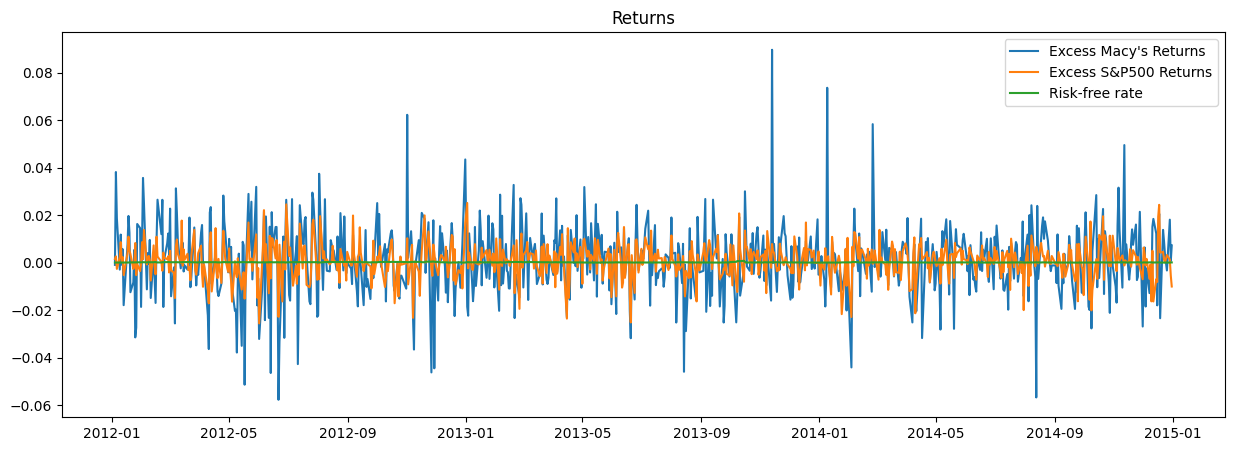

In [48]:
returns = pd.concat([one_day,m_returns,spy_returns],axis=1).dropna()#concatenate and drop missing values

excess_m = returns["Macy's Returns"] - returns['DGS1MO']
#Cpmplétez
excess_spy = returns["S&P500 Returns"] - returns['DGS1MO']
#print(excess_spy)
final_returns = pd.DataFrame(np.transpose([excess_m,excess_spy, returns['DGS1MO'].values]))
#print(final_returns)
final_returns.columns= ["Excess Macy's Returns", "Excess S&P500 Returns", "Risk-free rate"]
final_returns.index = returns.index
print(final_returns)
plt.figure(figsize=(15,5))
plt.title("Returns")
#x = plt.plot(final_returns);



for i in range(final_returns.columns.size):
    plt.plot(final_returns[final_returns.columns[i]], label=final_returns.columns[i])

plt.legend();

On considère la régression linéaire en utilisant les deux jeux de données.

In [75]:
import statsmodels.api as sm #pip install statsmodels


exog = final_returns["Excess S&P500 Returns"]
exog = sm.add_constant(exog, prepend=True)
#prepend=True the constant is given in the first column
mod = sm.OLS(final_returns["Excess Macy's Returns"], exog) #ordinary least squares
res_m = mod.fit()

print(res_m.summary())
print(res_m.params[0], res_m.params[1])

                              OLS Regression Results                             
Dep. Variable:     Excess Macy's Returns   R-squared:                       0.250
Model:                               OLS   Adj. R-squared:                  0.249
Method:                    Least Squares   F-statistic:                     248.1
Date:                   Sat, 06 Dec 2025   Prob (F-statistic):           1.81e-48
Time:                           09:39:22   Log-Likelihood:                 2175.6
No. Observations:                    747   AIC:                            -4347.
Df Residuals:                        745   BIC:                            -4338.
Df Model:                              1                                         
Covariance Type:               nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------


C:\Users\lione\AppData\Local\Temp\ipykernel_43004\759922304.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(res_m.params[0], res_m.params[1])


On obtient $\beta_{M}=1.0324$ et $\alpha=0.0003$, même si la valeur obtenue pour $\alpha$ n'est pas statistiquement signifiante elle reste consitente avec la théorie du CAPM qui prédit une moyenne nulle du surplus de rentabilité résiduel.  

Donc on peut décomposer le surplus de rentabilité en une composante du marché et une composante résiduelle. 

0.00032427740101577694


C:\Users\lione\AppData\Local\Temp\ipykernel_43004\650397308.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  market_c = res_m.params[1] * final_returns["Excess S&P500 Returns"]
C:\Users\lione\AppData\Local\Temp\ipykernel_43004\650397308.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  residual_c = market_c - res_m.params[0]


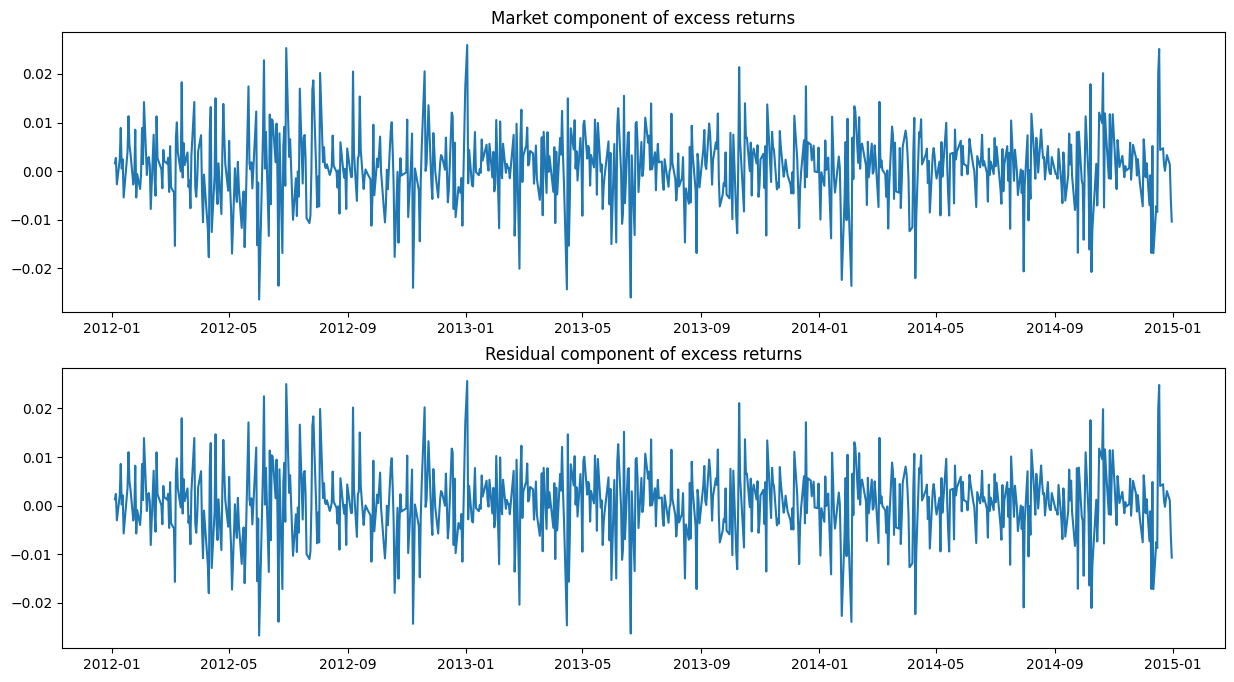

In [76]:
#Complétez #modèle du CAPM
market_c = res_m.params[1] * final_returns["Excess S&P500 Returns"]
residual_c = market_c - res_m.params[0]
print(residual_c.mean())


plt.figure(figsize=(15,8))
plt.subplot(211)
plt.title("Market component of excess returns");
plt.plot(final_returns.index,market_c);
plt.subplot(212)
plt.title("Residual component of excess returns");
plt.plot(final_returns.index,residual_c);

### Plus sur le CAPM

Sous les hypothèses du CAPM, un individu dont le portefeuille différe de celui du marché  a un t-risque additionnel sans rendement moyen additionnel. 


On étend l'analyse avec un actif additionnel **AMZN** (Amazon):

In [78]:
#compléter
a = yf.download('AMZN',  datetime(2012,1,1), datetime(2015,1,1))
a_returns = pd.DataFrame(np.log(a['Close']).diff())
a_returns.index = a.index[0:a.index.shape[0]]
a_returns.columns = ['Amazon Returns']

returns = pd.concat([one_day,a_returns], axis=1).dropna()
excess_a = returns['Amazon Returns'] - returns['DGS1MO']

print(excess_a)


C:\Users\lione\AppData\Local\Temp\ipykernel_43004\3986898982.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  a = yf.download('AMZN',  datetime(2012,1,1), datetime(2015,1,1))
[*********************100%***********************]  1 of 1 completed

2012-01-04   -0.008554
2012-01-05    0.000536
2012-01-06    0.027708
2012-01-09   -0.022455
2012-01-10    0.004331
                ...   
2014-12-24   -0.010728
2014-12-26    0.019773
2014-12-29    0.009472
2014-12-30   -0.005673
2014-12-31    0.000080
Length: 747, dtype: float64


On cherche les beta de chacun. 

In [81]:
mod = sm.OLS(excess_a, exog)
res_a = mod.fit()
print(res_a.summary())
print(res_a.params[0], res_a.params[1])

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.237
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     230.8
Date:                Sat, 06 Dec 2025   Prob (F-statistic):           1.32e-45
Time:                        09:53:51   Log-Likelihood:                 1994.4
No. Observations:                 747   AIC:                            -3985.
Df Residuals:                     745   BIC:                            -3976.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -0.00

C:\Users\lione\AppData\Local\Temp\ipykernel_43004\484457152.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(res_a.params[0], res_a.params[1])


Maintenant on considère les rendements annuels de nos deux actifs et on trace la forontière efficiente. 

[0.0466094  0.27006736 0.27731076 0.33018212]


C:\Users\lione\AppData\Local\Temp\ipykernel_43004\165816893.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  betas = np.array([0,1,res_m.params[1],res_a.params[1]])


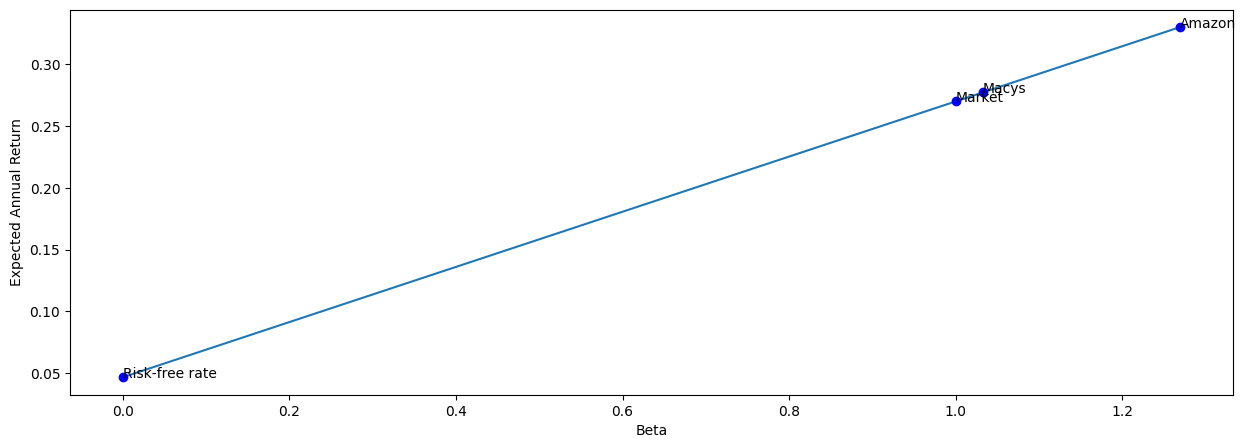

In [80]:
expected_spy = np.log(1+np.mean(excess_spy))*365 #rendement moyen annuel du SPY
betas = np.array([0,1,res_m.params[1],res_a.params[1]]) 
#Complétez
expected_rf = np.log(1+np.mean(returns['DGS1MO']))*365
expected_returns = betas*expected_spy+ expected_rf
data_names = ['Risk-free rate', 'Market','Macys','Amazon']
print(expected_returns)
plt.figure(figsize=(15,5))
plt.plot(betas,expected_returns);
plt.plot(betas,expected_returns,'bo')

for i, txt in enumerate(expected_returns):
    plt.annotate(data_names[i], (betas[i],expected_returns[i])) 


plt.xlabel("Beta");
plt.ylabel("Expected Annual Return");

La pente correspond à la moyenne des surplus de rendement du marché. 
Maintenant, regardons une prédiction du surplus 
rendement  ex-post pour l'année d'après. Pour simplifier, on supposera que beta et l'ASR restent les mêmes.

In [ ]:
a_new = yf.download('AMZN',   datetime(2015,1,2), datetime(2016,1,1))
a_new_price = a_new['Close'].values
a_annual = (a_new_price[-1]/a_new_price[0] - 1)

# expected_returns = res_a.params[1] * a_annual + expected_rf
#Complétez
m_new = yf.download('M',   datetime(2015,1,2), datetime(2016,1,1))
m_new_price = m_new['Close'].values
m_annual = (m_new_price[-1]/m_new_price[0] - 1)


spy_new = yf.download('SPY',   datetime(2015,1,2), datetime(2016,1,1))
spy_new_price = spy_new['Close'].values
spy_annual = (spy_new_price[-1]/spy_new_price[0] - 1)



expected_returns_real = [expected_rf, spy_annual[0], m_annual[0], a_annual[0]]
sml_real = betas * spy_annual#?    #market line

sml_real[0] = expected_returns[0] #market line



C:\Users\lione\AppData\Local\Temp\ipykernel_43004\2230552025.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  a_new = yf.download('AMZN',   datetime(2015,1,2), datetime(2016,1,1))
[*********************100%***********************]  1 of 1 completed
C:\Users\lione\AppData\Local\Temp\ipykernel_43004\2230552025.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  m_new = yf.download('M',   datetime(2015,1,2), datetime(2016,1,1))
[*********************100%***********************]  1 of 1 completed
C:\Users\lione\AppData\Local\Temp\ipykernel_43004\2230552025.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy_new = yf.download('SPY',   datetime(2015,1,2), datetime(2016,1,1))
[*********************100%***********************]  1 of 1 completed

[np.float64(0.04660940311043452), np.float64(0.012884919535694817), np.float64(-0.45351094801887315), np.float64(1.190749334186814)]


C:\Users\lione\AppData\Local\Temp\ipykernel_43004\276973487.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo" (-> color='b'). The keyword argument will take precedence.
  plt.plot(betas,expected_returns_real,'bo',c='g',label='Realized Returns')
C:\Users\lione\AppData\Local\Temp\ipykernel_43004\276973487.py:8: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo" (-> color='b'). The keyword argument will take precedence.
  plt.plot(betas,sml_real,'bo',c='r')


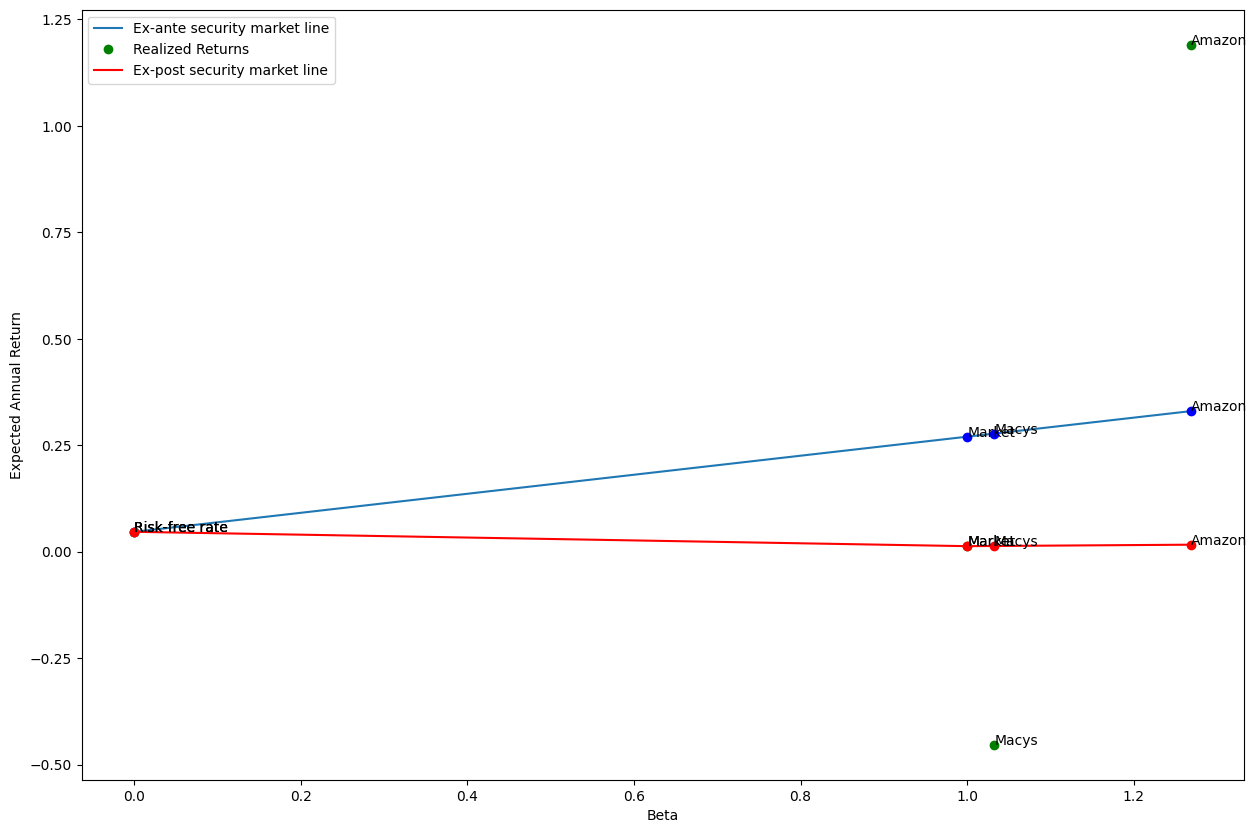

In [91]:
plt.figure(figsize=(15,10))

plt.plot(betas,expected_returns,label='Ex-ante security market line')
plt.plot(betas,expected_returns,'bo')
plt.plot(betas,expected_returns_real,'bo',c='g',label='Realized Returns')

plt.plot(betas,sml_real,c='r',label='Ex-post security market line')
plt.plot(betas,sml_real,'bo',c='r')  

for i, txt in enumerate(expected_returns):
    plt.annotate(data_names[i], (betas[i],expected_returns[i]))
  
for i, txt in enumerate(expected_returns):
    plt.annotate(data_names[i], (betas[i],sml_real[i]))    
    
for i, txt in enumerate(expected_returns):
    plt.annotate(data_names[i], (betas[i],expected_returns_real[i]))
    
plt.xlabel("Beta");
plt.ylabel("Expected Annual Return");
plt.legend(loc=2);

La courbe rouge nous dit ce que le CAPM aurait prédit si on connaissait le rendement du portefeuille de marché.